# Measure Scale
This project measures the scale of the crystal using the ArUco markers.  This effectively converts the x,y coordinates of the image to real-world units (in millimeters).

In [27]:
# Imports
import os
import sys
import time
import copy
import glob
import math
from math import pi, sqrt
import pickle

import numpy as np
import cv2 as cv
import pandas as pd
import pyvista as pv
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pylab as plt


# Settings
calibrationFolder = 'cal_images2'
imageScaleFactor = 0.125
outputCalibrationFile = 'Camera_Calibration_%.3f.pickle' % imageScaleFactor
calFilePath = './%s/%s' % (calibrationFolder, outputCalibrationFile)

imageFolderPath = 'small_white_crystal_supports'
resolution = np.array([5328, 4608])
scaleFactor_default = imageScaleFactor

# Make sure the calibration data exists
data = None
if (os.path.exists(calibrationFolder) == True) and (os.path.exists(calFilePath) == True):
    # Load the calibration data
    with open(calFilePath, 'rb') as f:
        data = pickle.load(f)
else:
    raise Exception(f'ERROR: Calibration file does not exist ({calFilePath})')

# Extract the data
mtx = data['mtx']
dist = data['dist']
rvecs = data['rvecs']
tvecs = data['tvecs']
checkScaleFactor = data['imageScaleFactor']
chessboardSquareSize = data['chessboardSquareSize_mm']
scaling = data['scalingFactor'] # mm / pixel

marker_size = 10.0  # ArUco Marker size


if checkScaleFactor != imageScaleFactor:
    raise Exception(f'Image scale factor for calibration data does not match the expected value! {checkScaleFactor} != {imageScaleFactor}')

fx = mtx[0,0]   # focal length (unit is in pixels)
fy = mtx[1,1]   # focal length (unit is in pixels)
cx = mtx[0,2]   # principle point (x coordinate).  Usually the center of the image.
cy = mtx[1,2]   # principle point (y coordinate).  Usually the center of the image.

print(mtx)

[[4.63484845e+04 0.00000000e+00 3.26964815e+02]
 [0.00000000e+00 4.62829199e+04 2.74777298e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


In [14]:

#-------------------------------------------------------------------------------
#                                   show_image
#-------------------------------------------------------------------------------
def show_image(title, opencvImage):
    
    plt.figure()
    # OpenCV stores images in BGR order instead of RGB, so convert
    plt.imshow(cv.cvtColor(opencvImage, cv.COLOR_BGR2RGB))
    plt.title(title)

    return


#-------------------------------------------------------------------------------
#                                   resize_image
#-------------------------------------------------------------------------------
def resize_image(img, newResolution=(64,64)):
    width = newResolution[0]
    height = newResolution[1]
    resized = cv.resize(img.copy(), (int(width), int(height)), interpolation=cv.INTER_AREA)
    return resized


#-------------------------------------------------------------------------------
#                               load_image
#-------------------------------------------------------------------------------
def load_image(degrees=0, scaleFactor=scaleFactor_default, folder=imageFolderPath):

    filePath = '%s/crystal_%04d.jpg' % (folder, degrees)
    #filePath = os.path.normpath(filePath)
    #filePath = os.path.abspath(filePath)

    img = None

    if os.path.exists(filePath):

        print(f'Loading "{filePath}...')
        img = cv.imread(filePath)

        h,w,_ = img.shape
        newRes = (w * scaleFactor, h * scaleFactor)
        img = resize_image(img, newRes)

    else:

        print(f'ERROR: Image file not found ({filePath})')

    return img


#-------------------------------------------------------------------------------
#                                  draw
#-------------------------------------------------------------------------------
def draw(drawImg, corners, imgpts, ArUco=True):
    ''' Draws a 3D axis on the ArUco Marker. '''
    
    # Open CV uses "BGR" instead of "RGB"
    blue = (255, 0, 0)
    green = (0, 255, 0)
    red = (0, 0, 255)

    lineThickness = 5

    print(imgpts)

    if ArUco == True:
        # Draw the R/G/B Axis Indicator
        pt1 = np.array(corners[0].ravel(), dtype=int)
        pt2a = np.array(imgpts[1].ravel(), dtype=int)
        pt2b = np.array(imgpts[3].ravel(), dtype=int)
        pt2c = np.array(imgpts[4].ravel(), dtype=int)

        drawImg = cv.line(drawImg, pt1, pt2a, blue, lineThickness)
        drawImg = cv.line(drawImg, pt1, pt2b, green, lineThickness)
        drawImg = cv.line(drawImg, pt1, pt2c, red, lineThickness)
    
    else:
        '''
        # Draw the R/G/B Axis Indicator
        pt1 = np.array(corners[0].ravel(), dtype=int)
        pt2a = np.array(imgpts[0].ravel(), dtype=int)
        pt2b = np.array(imgpts[1].ravel(), dtype=int)
        pt2c = np.array(imgpts[2].ravel(), dtype=int)

        drawImg = cv.line(drawImg, pt1, pt2a, blue, lineThickness)
        drawImg = cv.line(drawImg, pt1, pt2b, green, lineThickness)
        drawImg = cv.line(drawImg, pt1, pt2c, red, lineThickness)
        '''

        imgpts = np.int32(imgpts).reshape(-1,2)

        # draw ground floor in green
        basePoints = np.array([imgpts[:4]], dtype=int)
        drawImg = cv.drawContours(drawImg, basePoints, -1, green, -3)
        
        
        # draw pillars in blue color
        for i,j in zip(range(4),range(4,8)):
            pt1 = np.array(imgpts[i], dtype=int)
            pt2 = np.array(imgpts[j], dtype=int)
            drawImg = cv.line(drawImg, pt1, pt2, blue, lineThickness)
        
        # draw top layer in red color
        topPoints = np.array([imgpts[4:]], dtype=int)
        drawImg = cv.drawContours(drawImg, topPoints, -1, red, lineThickness)

    return drawImg

# Load an image

Loading "small_white_crystal_supports/crystal_0000.jpg...


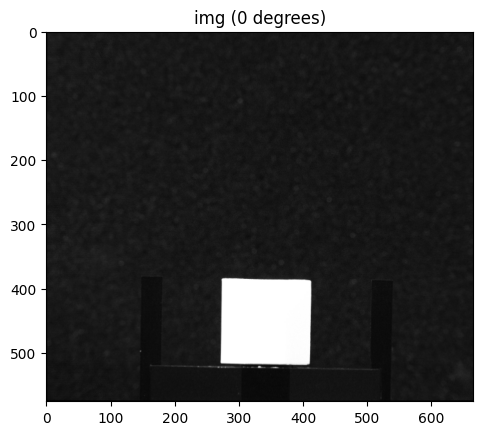

In [43]:
deg = 0   # 48 -> 50 is good for marker 0

# Load the image
img = load_image(deg)

# Undistort the image
img = cv.undistort(img, mtx, dist)

# Show the image
show_image(f'img ({deg} degrees)', img)

# Find the ArUco Marker

Corners: (array([[[213., 385.],
        [259., 386.],
        [258., 450.],
        [211., 448.]]], dtype=float32),)
ids: [[0]]
rejected: (array([[[292., 384.],
        [386., 387.],
        [406., 520.],
        [259., 520.]]], dtype=float32),)
Processing ArUco ID#[0]...
[[[212.75412 384.76016]]

 [[259.2461  386.2392 ]]

 [[257.75357 449.76062]]

 [[211.24625 448.24008]]

 [[256.099   385.23734]]

 [[302.5526  386.7231 ]]

 [[301.07733 450.1691 ]]

 [[254.60855 448.63586]]]


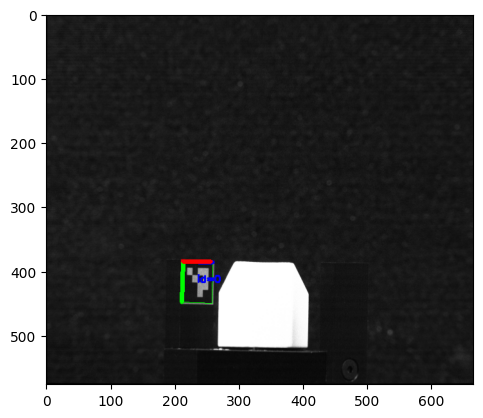

In [42]:
# Create a grayscale version of the image
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Make a copy of the image too
arucoImg2 = copy.deepcopy(img)

# Create aruco parameters
arucoParams = cv.aruco.DetectorParameters()

# Defined above:  aruco_dict = cv.aruco.getPredefinedDictionary(cv.aruco.DICT_4X4_50)  # 4x4 bits, minimum hamming distance between any two codes = 4, 50 codes
aruco_dict = cv.aruco.getPredefinedDictionary(cv.aruco.DICT_4X4_50)  # 4x4 bits, minimum hamming distance between any two codes = 4, 50 codes

# Create an ArUco detector object
detector = cv.aruco.ArucoDetector(aruco_dict, arucoParams)

# Find the markers
(corners, ids, rejected) = detector.detectMarkers(gray)

# Draw the markers
arucoImg2 = cv.aruco.drawDetectedMarkers(arucoImg2, corners, ids)

# OpenCV stores images in BGR order instead of RGB, so convert
#fig = plt.figure()
#plt.imshow(cv.cvtColor(arucoImg2, cv.COLOR_BGR2RGB))

print('Corners:', corners)
print('ids:', ids)
print('rejected:', rejected)


if len(corners) > 0:

    # Loop over each discovered marker
    #for c,id,r in zip(corners, ids, rejected):
    for c,id in zip(corners, ids):

        print(f'Processing ArUco ID#{id}...')
        
        # https://stackoverflow.com/questions/75750177/solve-pnp-or-estimate-pose-single-markers-which-is-better

        '''
        # For positive Y-axis (y coorindinates are bigger at the top of the image)
        marker_points = np.array([[-marker_size/2, marker_size/2, 0],
                                [marker_size/2, marker_size/2, 0],
                                [marker_size/2, -marker_size/2, 0],
                                [-marker_size/2, -marker_size/2, 0]], dtype=np.float32)

        marker_points_3d = np.array([[-marker_size/2, marker_size/2, 0],
                                    [marker_size/2, marker_size/2, 0],
                                    [marker_size/2, -marker_size/2, 0],
                                    [-marker_size/2, -marker_size/2, 0],
                                    [-marker_size/2, marker_size/2, marker_size],
                                    [marker_size/2, marker_size/2, marker_size],
                                    [marker_size/2, -marker_size/2, marker_size],
                                    [-marker_size/2, -marker_size/2, marker_size]
                                    ], dtype=np.float32)
        '''

        # For negative Y-axis (y coorindinates are smaller at the top of the image)
        marker_points = np.array([[-marker_size/2, -marker_size/2, 0],       # top left
                                [marker_size/2, -marker_size/2, 0],          # top right
                                [marker_size/2, marker_size/2, 0],           # bottom right
                                [-marker_size/2, marker_size/2, 0]],         # bottom left
                                dtype=np.float32)

        marker_points_3d = np.array([[-marker_size/2, -marker_size/2, 0],     # top left
                                    [marker_size/2, -marker_size/2, 0],        # top right
                                    [marker_size/2, marker_size/2, 0],         # bottom right
                                    [-marker_size/2, marker_size/2, 0],       # bottom left
                                    [-marker_size/2, -marker_size/2, marker_size],       # top-left, offset off of the surface
                                    [marker_size/2, -marker_size/2, marker_size],        # top-right, offset off of the surface
                                    [marker_size/2, marker_size/2, marker_size],         # botom right, offset off of the surface
                                    [-marker_size/2, marker_size/2, marker_size]         # bottom right, offset off of the surface
                                    ], dtype=np.float32)

        ret,rvecs,tvecs = cv.solvePnP(marker_points, c[0], mtx, dist, False, cv.SOLVEPNP_IPPE_SQUARE)

        # project 3D points to image plane
        axisScale = 1
        axis = np.float32([[0,0,0], [axisScale,0,0], [0,-axisScale,0], [0,0,axisScale]]).reshape(-1,3)
        #axis = np.float32([[0,0,0], [0,axisScale,0], [axisScale,axisScale,0], [axisScale,0,0], [0,0,-axisScale], [0,axisScale,-axisScale], [axisScale,axisScale,-axisScale], [axisScale,0,-axisScale]])

        imgpts, jac = cv.projectPoints(marker_points_3d, rvecs, tvecs, mtx, dist)

        # Draw the red/gree/blue lines indicating where the grid is
        arucoImg2 = draw(arucoImg2, c[0], imgpts, True)


    # OpenCV stores images in BGR order instead of RGB, so convert
    fig = plt.figure()
    plt.imshow(cv.cvtColor(arucoImg2, cv.COLOR_BGR2RGB))

else:
    print('ERROR: Could not find the corners of the ArUco marker.')

# Convert image coordinates to real-world units

# Notes:
1. Undistort the image
2. Estimate the camera angle (from the ArUco marker) -- use stage rotation for now...
3. Convert the pixels to millimeters
4. Figure out if the stage is occluding (render the stage where it should go based on camera angle from ArUco markers)